In [100]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [101]:
df = pd.read_csv('2026_02_06_ga_voting.csv')
df

/var/folders/5m/51l7xgkx5wb1pxpq6ly4l65c0000gn/T/ipykernel_47938/720716759.py:1: DtypeWarning: Columns (0: session, 1: vote_note) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('2026_02_06_ga_voting.csv')


,undl_id,ms_code,ms_name,ms_vote,date,session,resolution,draft,committee_report,meeting,title,agenda_title,subjects,vote_note,total_yes,total_no,total_abstentions,total_non_voting,total_ms,undl_link
0,507407,AFG,AFGHANISTAN,Y,2003-12-03,58,A/RES/58/20,A/58/L.25|A/58/L.25/Add.1,NaN,A/58/PV.68,Special information programme on the question ...,Question of Palestine.,PALESTINE QUESTION,NaN,159.0,6.0,6.0,20.0,191.0,https://digitallibrary.un.org/record/507407
1,507407,ALB,ALBANIA,Y,2003-12-03,58,A/RES/58/20,A/58/L.25|A/58/L.25/Add.1,NaN,A/58/PV.68,Special information programme on the question ...,Question of Palestine.,PALESTINE QUESTION,NaN,159.0,6.0,6.0,20.0,191.0,https://digitallibrary.un.org/record/507407
2,507407,DZA,ALGERIA,Y,2003-12-03,58,A/RES/58/20,A/58/L.25|A/58/L.25/Add.1,NaN,A/58/PV.68,Special information programme on the question ...,Question of Palestine.,PALESTINE QUESTION,NaN,159.0,6.0,6.0,20.0,191.0,https://digitallibrary.un.org/record/507407
3,507407,AND,ANDORRA,Y,2003-12-03,58,A/RES/58/20,A/58/L.25|A/58/L.25/Add.1,NaN,A/58/PV.68,Special information programme on the question ...,Question of Palestine.,PALESTINE QUESTION,NaN,159.0,6.0,6.0,20.0,191.0,https://digitallibrary.un.org/record/507407
4,507407,AGO,ANGOLA,X,2003-12-03,58,A/RES/58/20,A/58/L.25|A/58/L.25/Add.1,NaN,A/58/PV.68,Special information programme on the question ...,Question of Palestine.,PALESTINE QUESTION,NaN,159.0,6.0,6.0,20.0,191.0,https://digitallibrary.un.org/record/507407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947429,4088513,VEN,VENEZUELA (BOLIVARIAN REPUBLIC OF),X,2025-09-19,80,A/RES/80/1,A/80/L.2/Rev.1,NaN,A/80/PV.3,Participation by the State of Palestine during...,"Organization of work, adoption of the agenda a...",UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...,NaN,145.0,5.0,6.0,37.0,193.0,https://digitallibrary.un.org/record/4088513
947430,4088513,VNM,VIET NAM,Y,2025-09-19,80,A/RES/80/1,A/80/L.2/Rev.1,NaN,A/80/PV.3,Participation by the State of Palestine during...,"Organization of work, adoption of the agenda a...",UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...,NaN,145.0,5.0,6.0,37.0,193.0,https://digitallibrary.un.org/record/4088513
947431,4088513,YEM,YEMEN,Y,2025-09-19,80,A/RES/80/1,A/80/L.2/Rev.1,NaN,A/80/PV.3,Participation by the State of Palestine during...,"Organization of work, adoption of the agenda a...",UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...,NaN,145.0,5.0,6.0,37.0,193.0,https://digitallibrary.un.org/record/4088513
947432,4088513,ZMB,ZAMBIA,X,2025-09-19,80,A/RES/80/1,A/80/L.2/Rev.1,NaN,A/80/PV.3,Participation by the State of Palestine during...,"Organization of work, adoption of the agenda a...",UN. GENERAL ASSEMBLY (80TH SESS. : 2025-2026)-...,NaN,145.0,5.0,6.0,37.0,193.0,https://digitallibrary.un.org/record/4088513


In [102]:
keywords = 'military|arms|defen[sc]e|security|weapon|nuclear|intervention|missile|peace'

In [103]:
df_filtered = df.copy()

mask_title = df_filtered['title'].fillna('').str.contains(keywords, case=False, regex=True)
mask_agenda = df_filtered['agenda_title'].fillna('').str.contains(keywords, case=False, regex=True)
mask_subjects = df_filtered['subjects'].fillna('').str.contains(keywords, case=False, regex=True)

security_df = df_filtered[mask_title | mask_agenda | mask_subjects].copy()

In [104]:
votes = security_df[['undl_id', 'date', 'ms_code', 'ms_vote']].drop_duplicates()
vote_pivot = votes.pivot(index=['undl_id', 'date'], columns='ms_code', values='ms_vote').reset_index()
vote_pivot['year'] = pd.to_datetime(vote_pivot['date']).dt.year
vote_pivot = vote_pivot.sort_values('date')

In [107]:
def calculate_alignment(pivot_df, target_country, great_powers):
    results = pivot_df[['undl_id', 'date', 'year']].copy()
    
    for gp in great_powers:
        v1 = pivot_df[target_country]
        v2 = pivot_df[gp]
        
        same = (v1 == v2) & v1.isin(['Y', 'N', 'A'])
        partial = ((v1 == 'A') & v2.isin(['Y', 'N'])) | ((v2 == 'A') & v1.isin(['Y', 'N']))
        opposed = ((v1 == 'Y') & (v2 == 'N')) | ((v1 == 'N') & (v2 == 'Y'))
        
        scores = np.select(
            [same, partial, opposed],
            [1.0, 0.5, 0.0],
            default=np.nan 
        )
        
        results[f'Align_{gp}'] = scores
        
    return results

target = 'IND' 
powers = ['USA', 'CHN', 'RUS', 'SUN']

alignment_df = calculate_alignment(vote_pivot, target, powers)
annual_alignment = alignment_df.groupby('year')[[f'Align_{gp}' for gp in powers]].mean()



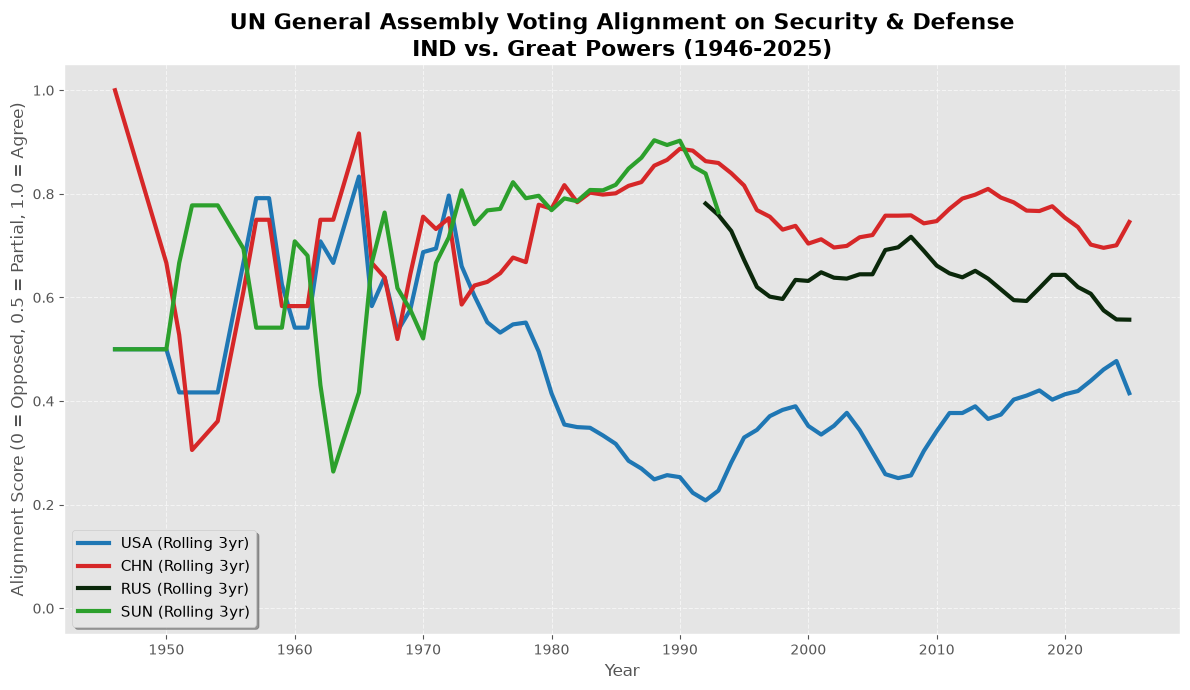

In [108]:
window = 3
rolling_alignment = annual_alignment.rolling(window=window, min_periods=1).mean()

plt.style.use('ggplot') 
fig, ax = plt.subplots(figsize=(12, 7))

colors = {'USA': '#1f77b4', 'CHN': '#d62728', 'RUS': '#0b280b', 'SUN' : '#2ca02c'}

for gp in powers:
    ax.plot(rolling_alignment.index, rolling_alignment[f'Align_{gp}'], 
            label=f'{gp} (Rolling {window}yr)', color=colors[gp], linewidth=3)
    

min_year = annual_alignment.index.min()
max_year = annual_alignment.index.max()

ax.set_title(f"UN General Assembly Voting Alignment on Security & Defense\n{target} vs. Great Powers ({min_year}-{max_year})", fontsize=16, weight='bold')
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Alignment Score (0 = Opposed, 0.5 = Partial, 1.0 = Agree)", fontsize=12)
ax.set_ylim(-0.05, 1.05)

ax.grid(True, which='both', linestyle='--', alpha=0.6)
ax.legend(loc='lower left', fontsize=11, frameon=True, shadow=True)

plt.tight_layout()
plt.show()
